Importar librerías y dataset

In [1]:
import pandas as pd
import os

#Import the dataset
dataset = os.path.join('..','Lorca_processed.csv')
                               
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

print("Número de filas tras filtrar: " + str(len(data)))

data.head(10)

Número de filas tras filtrar: 1944


,temperature,windSpeed,solarRad,humedad,rain,Power_gen,pressure_sensor,pressure,month,day,hour,minute
0,10.5556,0.00000,0,57,0.0,0.0000,170.602742,28.991,2,6,4,54
1,17.6667,17.70280,504,39,0.0,2.8780,385.968892,28.960,3,5,12,9
2,17.6111,9.65606,626,40,0.0,5.7560,385.426481,28.962,3,5,12,14
3,18.0556,16.09340,664,42,0.0,8.6340,385.411336,28.961,3,5,12,19
4,17.6111,1.60934,664,38,0.0,11.5120,385.049863,28.959,3,5,12,24
5,18.5000,4.82803,682,37,0.0,9.2096,385.366369,28.932,3,5,13,24
6,18.6111,12.87480,680,38,0.0,6.9072,385.503740,28.931,3,5,13,29
7,18.5556,12.87480,617,39,0.0,4.6048,385.154409,28.928,3,5,13,34
8,18.1667,9.65606,619,37,0.0,2.3024,385.622396,28.926,3,5,13,39
9,18.2222,4.82803,670,38,0.0,0.0000,385.252950,28.923,3,5,13,44


Separamos las variables predictoras y objetivo.

In [2]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [3]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo.

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'n_estimators': [50, 100, 900], #numero de arboles
          'max_features': [1, 'sqrt', None]}
pruebas = RandomForestRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 27 candidates, totalling 54 fits
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END .......max_depth=2, max_features=1, n_estimators=50; total time=   0.0s
[CV] END ......max_depth=2, max_features=1, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=1, n_estimators=100; total time=   0.0s
[CV] END ......max_depth=2, max_features=1, n_estimators=900; total time=   0.6s
[CV] END ......max_depth=2, max_features=1, n_estimators=900; total time=   0.7s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END ....max_depth=2, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.0s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=100; total time=   0.0s
[CV] END ...max_depth=2, max_features=sqrt, n_estimators=900; total time=   0.7s
[CV] END ...max_depth=2, max_features=sqrt, n_es

Creamos el modelos y controlamos el sobreajuste.

In [21]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(max_depth = 9, max_features ='sqrt',n_estimators = 900) #aplicamos los parametros optimos obtenidos
rfr.fit(X_train, y_train)  #entrenamos el modelo

,n_estimators,900
,criterion,'squared_error'
,max_depth,9
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Predicción y análisis

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = rfr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
r2_ajustado = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)

print("MAE: ", mae) #MAE = Error medio en la prediccion
print("MSE:", mse) #MSE = Error cuadratico medio en la prediccion
print("RMSE:", rmse) #RMSE = Raiz del error cuadratico medio en la prediccion
print("R²:", r2) #R^2 = Coeficiente de determinacion
print("R2 ajustado:", r2_ajustado) #R^2 ajustado, si es parecido al normal indica que no hay overfitting ni variables irrelevantes

MAE:  1.5274614860006168
MSE: 5.805748933794106
RMSE: 2.409512177556716
R²: 0.857784979931112
R2 ajustado: 0.853635470061728


Obtener varaibles más importantes en la predicción

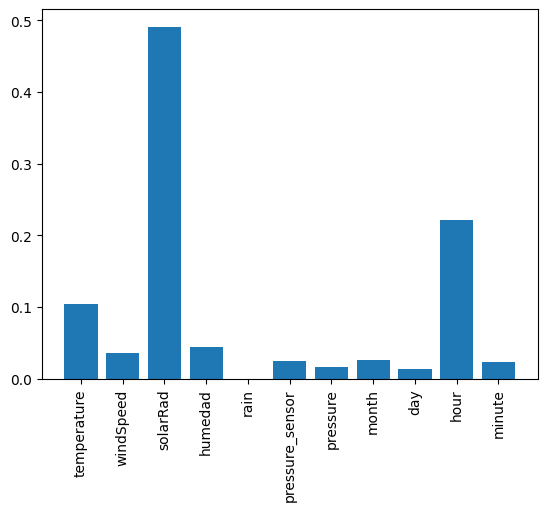

In [24]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, rfr.feature_importances_)
plt.xticks(rotation=90)
plt.show()

Comparativa predicción vs realidad

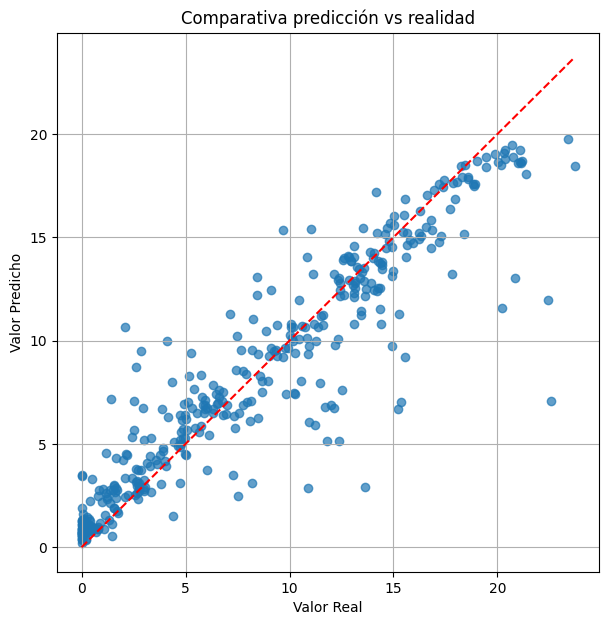

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
